In [1]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#### Data Preparation

In [2]:
iris = load_iris()
y = iris.target
names = iris.target_names
X = iris.data
features = iris.feature_names

In [27]:
df = pd.DataFrame(X,columns=features)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
df["flower"] = y

In [30]:
df["flowerName"] = df["flower"].apply(lambda x: names[x])

In [31]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower,flowerName
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [32]:
df.to_csv("./iris.csv",index=False)

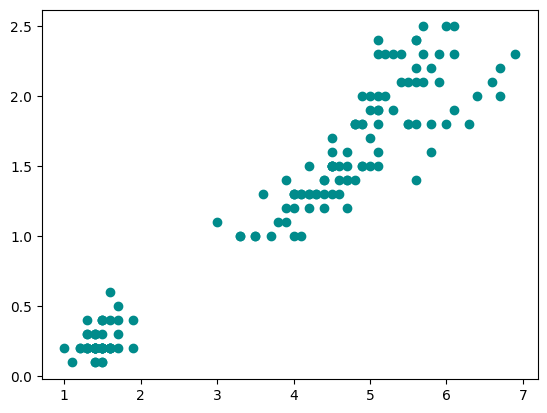

In [79]:
plt.scatter(df["petal length (cm)"],df["petal width (cm)"],c="darkcyan")


#### Check the number of clusters by elbow method

c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Sakhi Larik\AppData\Local\Programs\Python\Python311\Lib\si

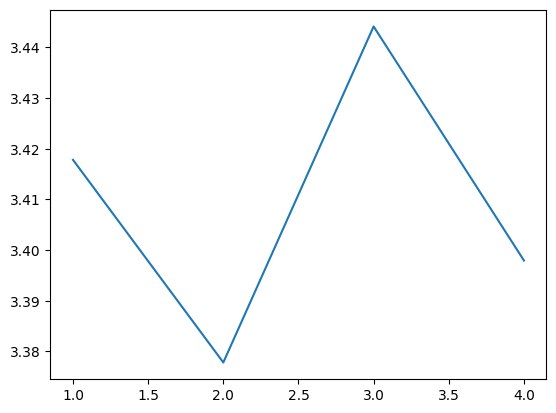

In [49]:
sse =[]
for k in range(1,5):
    KM = KMeans()
    KM.fit_predict(df[["petal length (cm)"]],df[["petal width (cm)"]])
    sse.append(KM.inertia_)

plt.plot(range(1,5),sse)

#### So here KMeans Went Wrong :(

In [54]:
multi = MultiOutputClassifier(LogisticRegression(),n_jobs=50).fit(X, df[["flower"]])

In [56]:
predict = multi.predict(X)

In [60]:
multi.score(X,df[["flower"]])

0.9733333333333334

In [61]:
df["predicted"] = predict

In [65]:
df["predicted"].unique()

array([0, 1, 2])

In [63]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),flower,flowerName,predicted
145,6.7,3.0,5.2,2.3,2,virginica,2
146,6.3,2.5,5.0,1.9,2,virginica,2
147,6.5,3.0,5.2,2.0,2,virginica,2
148,6.2,3.4,5.4,2.3,2,virginica,2
149,5.9,3.0,5.1,1.8,2,virginica,2


In [76]:
df1 = df[df["predicted"] == 0]
df2 = df[df["predicted"] == 1]
df3 = df[df["predicted"] == 2]

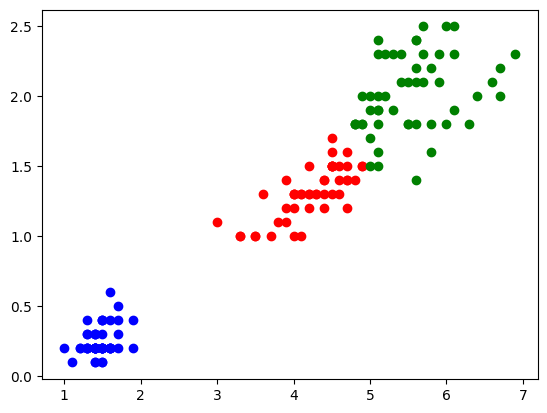

In [77]:
plt.scatter(df1["petal length (cm)"],df1["petal width (cm)"],c="blue")

plt.scatter(df2["petal length (cm)"],df2["petal width (cm)"],c="red")

plt.scatter(df3["petal length (cm)"],df3["petal width (cm)"],c="green")